In [1]:
import os
import numpy as np
import cv2

import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import feature

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

import joblib

In [2]:
# Para hacer las matrices de confusión (a mano)

acc_pca_folds = []
acc_hog_folds = []
acc_lbp_folds = []

cm_pca_folds = []
cm_hog_folds = []
cm_lbp_folds = []

In [3]:
def lbphist(gray, ncellsx, ncellsy, width, height, type):
    print(f"[DEBUG] Entrando en lbphist con shape={gray.shape}")
    pxpercellx = int(width/ncellsx)
    pxpercelly = int(height/ncellsy)
    ofx = int((width - int(pxpercellx)*ncellsx)/2)
    ofy = int((height - int(pxpercelly)*ncellsy)/2)
    LBPu_hist = []
    for i in range(ncellsy):
        for j in range(ncellsx):
            roi = gray[ofy+i*pxpercelly:ofy+(i+1)*pxpercelly,
                       ofx+j*pxpercellx:ofx+(j+1)*pxpercellx]
            print(f"[DEBUG] ROI ({i},{j}) shape: {roi.shape}")
            lbpimg = feature.local_binary_pattern(roi, 8, 1, method=type)

            # Usar siempre 256 bins para evitar la redimensión que tienen nuestras fotos
            n_bins = 256
            feath, bins = np.histogram(lbpimg, density=False,
                                       bins=n_bins, range=(0, n_bins))

            LBPu_hist = np.concatenate([LBPu_hist, feath])
    print(f"[DEBUG] LBPu_hist final shape: {LBPu_hist.shape}")
    return LBPu_hist


def GetLBP(X, ncellsx, ncellsy, width, height, lbptype):
    Xlbp = []
    for idx, img_flat in enumerate(X):
        gray = img_flat.reshape(height, width)
        print(f"[DEBUG] Procesando imagen {idx} con shape {gray.shape}")
        feat_lbp = lbphist(gray, ncellsx, ncellsy, width, height, lbptype)
        Xlbp.append(feat_lbp)
        print(f"[DEBUG] Imagen {idx} procesada correctamente.")
    return Xlbp

def GetHOG(X, ncellsx, ncellsy, width, height):
    Xhog = []
    for i in range(len(X)):
        gray = X[i].reshape(height, width)
        feat_hog, hog_image = hog(gray, orientations=8,
                                  pixels_per_cell=(int(height/ncellsy), int(width/ncellsx)),
                                  cells_per_block=(1, 1), visualize=True, block_norm='L1')
        Xhog.append(feat_hog)
    return Xhog

def GetPredictions(X_train, X_test, y_train, y_test):
    scaler = MinMaxScaler()
    train_X = scaler.fit_transform(X_train)
    test_X = scaler.transform(X_test)
    parameters = {'C': [1e3, 5e3], 'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01]}
    clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), parameters, cv=5)
    clf = clf.fit(train_X, y_train)
    y_pred = clf.predict(test_X)
    return y_pred, y_test, clf

def LoadDataset(folder, ext):
    X, Y, classlabels = [], [], []
    width, height = None, None

    for class_id, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for file_name in os.listdir(class_folder):
            if file_name.endswith(ext):
                image = cv2.imread(os.path.join(class_folder, file_name))
                if image is None:
                    print(f"[WARN] No se pudo leer la imagen: {file_name}")
                    continue

                # Definir tamaño de referencia con la primera imagen
                if width is None or height is None:
                    h0, w0, _ = image.shape
                    width, height = w0, h0
                    print(f"[DEBUG] Tamaño de referencia: width={width}, height={height}")

                # Redimensionar todas al mismo tamaño
                image = cv2.resize(image, (width, height))

                gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                X.append(gray.reshape(height * width))
                Y.append(class_id)
        classlabels.append(class_name)

    return np.array(X, dtype="float32"), np.array(Y, dtype="float64"), classlabels, width, height

# ---- Cargar tu dataset ----
folder = "C:/Users/User/Desktop/Cuarto/VC/P5/dataset_barba"  # MODIFICA AQUÍ TU RUTA
print('Cargando datos...')
X, Y, classlabels, width, height = LoadDataset(folder, '.jpg')  # Usa '.jpg' si aplicas JPG
X = np.array(X, dtype='float32')
Y = np.array(Y, dtype='float64')
n_classes = len(classlabels)

# ---- Extraer descriptores HOG y LBP ----
Xhog4x4 = np.array(GetHOG(X, 4, 4, width, height), dtype='float32')

Xlbp_list = GetLBP(X, 3, 3, width, height, "nri_uniform")

# DEBUG: comprobar longitudes
lengths = [len(v) for v in Xlbp_list]
print("[DEBUG] Número de imágenes:", len(Xlbp_list))
print("[DEBUG] Longitudes únicas de los vectores LBP:", set(lengths))

# DEBE tener un único valor, porque las imágenes tienen distinto valor (en mi caso al menos)
Xlbp3x3 = np.array(Xlbp_list, dtype='float32')


Cargando datos...
[DEBUG] Tamaño de referencia: width=178, height=218
[DEBUG] Procesando imagen 0 con shape (218, 178)
[DEBUG] Entrando en lbphist con shape=(218, 178)
[DEBUG] ROI (0,0) shape: (72, 59)
[DEBUG] ROI (0,1) shape: (72, 59)
[DEBUG] ROI (0,2) shape: (72, 59)
[DEBUG] ROI (1,0) shape: (72, 59)
[DEBUG] ROI (1,1) shape: (72, 59)
[DEBUG] ROI (1,2) shape: (72, 59)
[DEBUG] ROI (2,0) shape: (72, 59)
[DEBUG] ROI (2,1) shape: (72, 59)
[DEBUG] ROI (2,2) shape: (72, 59)
[DEBUG] LBPu_hist final shape: (2304,)
[DEBUG] Imagen 0 procesada correctamente.
[DEBUG] Procesando imagen 1 con shape (218, 178)
[DEBUG] Entrando en lbphist con shape=(218, 178)
[DEBUG] ROI (0,0) shape: (72, 59)
[DEBUG] ROI (0,1) shape: (72, 59)
[DEBUG] ROI (0,2) shape: (72, 59)
[DEBUG] ROI (1,0) shape: (72, 59)
[DEBUG] ROI (1,1) shape: (72, 59)
[DEBUG] ROI (1,2) shape: (72, 59)
[DEBUG] ROI (2,0) shape: (72, 59)
[DEBUG] ROI (2,1) shape: (72, 59)
[DEBUG] ROI (2,2) shape: (72, 59)
[DEBUG] LBPu_hist final shape: (2304,)
[D

c:\Users\User\.conda\envs\VC_P5\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


[DEBUG] ROI (1,0) shape: (72, 59)
[DEBUG] ROI (1,1) shape: (72, 59)
[DEBUG] ROI (1,2) shape: (72, 59)
[DEBUG] ROI (2,0) shape: (72, 59)
[DEBUG] ROI (2,1) shape: (72, 59)
[DEBUG] ROI (2,2) shape: (72, 59)
[DEBUG] LBPu_hist final shape: (2304,)
[DEBUG] Imagen 35 procesada correctamente.
[DEBUG] Procesando imagen 36 con shape (218, 178)
[DEBUG] Entrando en lbphist con shape=(218, 178)
[DEBUG] ROI (0,0) shape: (72, 59)
[DEBUG] ROI (0,1) shape: (72, 59)
[DEBUG] ROI (0,2) shape: (72, 59)
[DEBUG] ROI (1,0) shape: (72, 59)
[DEBUG] ROI (1,1) shape: (72, 59)
[DEBUG] ROI (1,2) shape: (72, 59)
[DEBUG] ROI (2,0) shape: (72, 59)
[DEBUG] ROI (2,1) shape: (72, 59)
[DEBUG] ROI (2,2) shape: (72, 59)
[DEBUG] LBPu_hist final shape: (2304,)
[DEBUG] Imagen 36 procesada correctamente.
[DEBUG] Procesando imagen 37 con shape (218, 178)
[DEBUG] Entrando en lbphist con shape=(218, 178)
[DEBUG] ROI (0,0) shape: (72, 59)
[DEBUG] ROI (0,1) shape: (72, 59)
[DEBUG] ROI (0,2) shape: (72, 59)
[DEBUG] ROI (1,0) shape: (

In [4]:
# ---- Proceso experimental: StratifiedKFold ----
kfold = 5
skf = StratifiedKFold(n_splits=kfold, random_state=4, shuffle=True)

for fold, (train_index, test_index) in enumerate(skf.split(X, Y), start=1):
    print(f"\nFold {fold}")
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]
    Xhog4x4_train, Xhog4x4_test = Xhog4x4[train_index], Xhog4x4[test_index]
    Xlbp3x3_train, Xlbp3x3_test = Xlbp3x3[train_index], Xlbp3x3[test_index]

    # PCA (95%)
    pca_95 = PCA(.95).fit(X_train)
    X_train_pca_95 = pca_95.transform(X_train)
    X_test_pca_95 = pca_95.transform(X_test)
    
    # PCA + SVM
    print("Entrenando PCA + SVM...")
    y_pred_pca_svm, y_test_pca_svm, svm_pca = GetPredictions(X_train_pca_95, X_test_pca_95, y_train, y_test)
    print("Métricas PCA + SVM")
    print(classification_report(y_test_pca_svm, y_pred_pca_svm, target_names=classlabels))

    # HOG + SVM
    print("Entrenando HOG + SVM...")
    y_pred_hog_svm, y_test_hog_svm, svm_hog = GetPredictions(Xhog4x4_train, Xhog4x4_test, y_train, y_test)
    print("Métricas HOG + SVM")
    print(classification_report(y_test_hog_svm, y_pred_hog_svm, target_names=classlabels))

    # LBP + SVM
    print("Entrenando LBP + SVM...")
    y_pred_lbp_svm, y_test_lbp_svm, svm_lbp = GetPredictions(Xlbp3x3_train, Xlbp3x3_test, y_train, y_test)
    print("Métricas LBP + SVM")
    print(classification_report(y_test_lbp_svm, y_pred_lbp_svm, target_names=classlabels))

    # Guardar el mejor modelo SOLO del primer fold (puedes adaptar esto según tus preferencias)
    if fold == 1:
        joblib.dump(svm_pca, "svm_pca_barba.joblib")
        joblib.dump(pca_95, "pca_barba.joblib")
        joblib.dump(svm_hog, "svm_hog_barba.joblib")
        joblib.dump(svm_lbp, "svm_lbp_barba.joblib")
        print("Modelos guardados para despliegue interactivo.")

    # PCA + SVM
    print("Entrenando PCA + SVM...")
    y_pred_pca_svm, y_test_pca_svm, svm_pca = GetPredictions(X_train_pca_95, X_test_pca_95, y_train, y_test)
    print("Métricas PCA + SVM")
    print(classification_report(y_test_pca_svm, y_pred_pca_svm, target_names=classlabels))

    acc_pca = (y_pred_pca_svm == y_test_pca_svm).mean()
    acc_pca_folds.append(acc_pca)
    cm_pca = confusion_matrix(y_test_pca_svm, y_pred_pca_svm)
    cm_pca_folds.append(cm_pca)

    # HOG + SVM
    print("Entrenando HOG + SVM...")
    y_pred_hog_svm, y_test_hog_svm, svm_hog = GetPredictions(Xhog4x4_train, Xhog4x4_test, y_train, y_test)
    print("Métricas HOG + SVM")
    print(classification_report(y_test_hog_svm, y_pred_hog_svm, target_names=classlabels))

    acc_hog = (y_pred_hog_svm == y_test_hog_svm).mean()
    acc_hog_folds.append(acc_hog)
    cm_hog = confusion_matrix(y_test_hog_svm, y_pred_hog_svm)
    cm_hog_folds.append(cm_hog)

    # LBP + SVM
    print("Entrenando LBP + SVM...")
    y_pred_lbp_svm, y_test_lbp_svm, svm_lbp = GetPredictions(Xlbp3x3_train, Xlbp3x3_test, y_train, y_test)
    print("Métricas LBP + SVM")
    print(classification_report(y_test_lbp_svm, y_pred_lbp_svm, target_names=classlabels))

    acc_lbp = (y_pred_lbp_svm == y_test_lbp_svm).mean()
    acc_lbp_folds.append(acc_lbp)
    cm_lbp = confusion_matrix(y_test_lbp_svm, y_pred_lbp_svm)
    cm_lbp_folds.append(cm_lbp)



Fold 1
Entrenando PCA + SVM...
Métricas PCA + SVM
              precision    recall  f1-score   support

   con_barba       0.73      0.81      0.77        54
   sin_barba       0.79      0.70      0.75        54

    accuracy                           0.76       108
   macro avg       0.76      0.76      0.76       108
weighted avg       0.76      0.76      0.76       108

Entrenando HOG + SVM...
Métricas HOG + SVM
              precision    recall  f1-score   support

   con_barba       0.67      0.74      0.70        54
   sin_barba       0.71      0.63      0.67        54

    accuracy                           0.69       108
   macro avg       0.69      0.69      0.68       108
weighted avg       0.69      0.69      0.68       108

Entrenando LBP + SVM...
Métricas LBP + SVM
              precision    recall  f1-score   support

   con_barba       0.78      0.80      0.79        54
   sin_barba       0.79      0.78      0.79        54

    accuracy                           0.79  

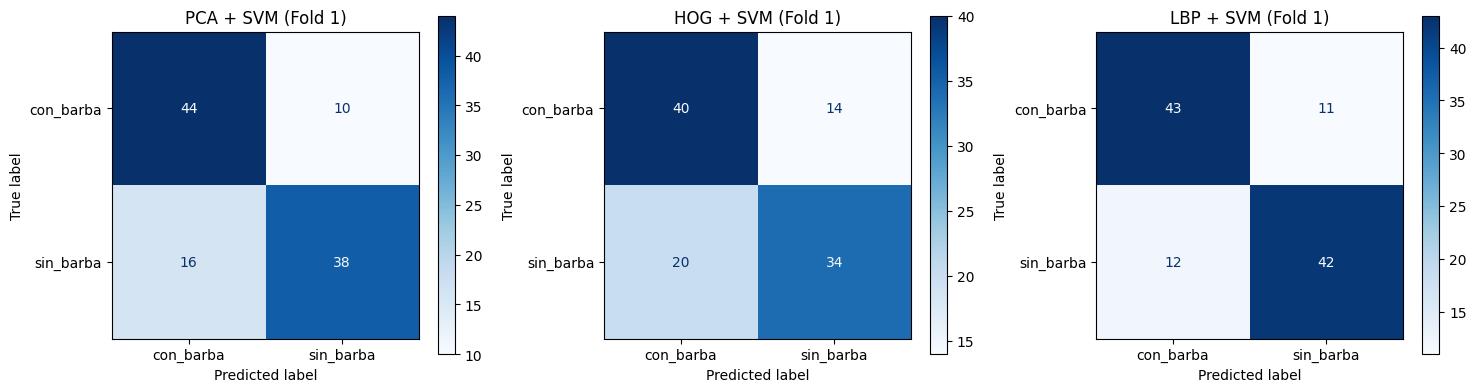

In [5]:
# Ejemplo: matrices de confusión del primer fold
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
ConfusionMatrixDisplay(cm_pca_folds[0], display_labels=classlabels).plot(values_format='d', cmap='Blues', ax=plt.gca())
plt.title('PCA + SVM (Fold 1)')

plt.subplot(1, 3, 2)
ConfusionMatrixDisplay(cm_hog_folds[0], display_labels=classlabels).plot(values_format='d', cmap='Blues', ax=plt.gca())
plt.title('HOG + SVM (Fold 1)')

plt.subplot(1, 3, 3)
ConfusionMatrixDisplay(cm_lbp_folds[0], display_labels=classlabels).plot(values_format='d', cmap='Blues', ax=plt.gca())
plt.title('LBP + SVM (Fold 1)')

plt.tight_layout()
plt.show()